# 31 · E2 Read Disturb Dose Matrix · 真器件

> ⚠️ 真连 B1500，接 pFeFET 器件。前置：E1 (30) PASS。

**目的 (H5)**：判断读操作本身是否破坏器件状态。

序列（每个数据点独立）：Reset → Write(ERS or PGM) → dose(mode, N 次) → verify_read(3pt)

| Mode | 描述 |
|------|------|
| A | 单次 5μs 脉冲 @ Vg=0V（最小扰动基准）|
| B | 11 步小阶梯 Vg=−0.5→+0.5V，每步 5μs |
| C | 准静态扫描 Vg=−1.5→+1.5V，每步 2ms（21步）|

**结论准则**：若 Mode A 给正 MW 而 Mode C 给负 MW → 读扰是真实的。

测试人：**yhzang**

In [1]:
import sys, os, time, random, datetime, itertools
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fefetlab.measurements.wgfmu import (
    ensure_wgfmu_dll_path, autodetect_visa_addr, clear_b1500_status_for_wgfmu_open,
    autodetect_wgfmu_chan, RealWgfmuBackend,
)

print("Python:", sys.version.split()[0])
print("project root:", ROOT)

Python: 3.13.5
project root: D:\test\B1500


In [2]:
dll = ensure_wgfmu_dll_path()
print(f"✅ wgfmu.dll: {dll}")

VISA_ADDR = autodetect_visa_addr("B1500")
print(f"✅ B1500 VISA addr: {VISA_ADDR}")

backend = RealWgfmuBackend()
backend.load()
idn = clear_b1500_status_for_wgfmu_open(VISA_ADDR)
print(f"B1500 preflight ERRX drain OK: {idn}")
backend.open_session(VISA_ADDR)
backend.set_timeout(30.0)
channel_ids = backend.get_channel_ids()
print(f"detected channels: {channel_ids}")

GATE_CH  = 202   # hardcoded: Gate=CH202 per yhzang wiring
DRAIN_CH = 201   # hardcoded: Drain=CH201 per yhzang wiring
assert GATE_CH in channel_ids and DRAIN_CH in channel_ids
print(f"✅ gate={GATE_CH}, drain={DRAIN_CH}")
backend.close_session()

✅ wgfmu.dll: C:\Windows\System32\wgfmu.dll
✅ B1500 VISA addr: GPIB1::17::INSTR
detected channels: [201, 202, 301, 302]
✅ gate=202, drain=201


0

In [3]:
# ── USER-EDITABLE PARAMETERS ──────────────────────────────────
QUICK_MODE  = True        # True: N_read=[1,10,100], modes=[A,C], 3 reps

DEVICE_ID   = "dev001"
GEOMETRY    = "W5L10"

V_ERS       = +5.0        # V
V_PGM       = -5.0        # V
T_WRITE     = 100e-6      # s
T_RISE_FALL = 100e-9      # s
T_RESET     = 1e-3        # s
T_NEUTRAL   = 100e-6      # s  gap between dose and verify

VG_READS    = [-0.2, 0.0, +0.2]  # V, verify read voltages
VD_READ     = 0.05                # V
T_READ      = 5e-6                # s
N_PTS_READ  = 5

N_READ_QUICK = [1, 10, 100]
N_READ_FULL  = [1, 3, 10, 30, 100]
MODES_QUICK  = ["A", "C"]
MODES_FULL   = ["A", "B", "C"]

N_REPS_QUICK = 3
N_REPS_FULL  = 5
RANDOM_SEED  = 42
# ── END PARAMETERS ────────────────────────────────────────────

n_read_sweep = N_READ_QUICK if QUICK_MODE else N_READ_FULL
modes        = MODES_QUICK  if QUICK_MODE else MODES_FULL
N_REPS       = N_REPS_QUICK if QUICK_MODE else N_REPS_FULL
TAG          = "quick" if QUICK_MODE else "full"

combos = list(itertools.product(["ERS", "PGM"], modes, n_read_sweep))
print(f"Mode  : {TAG}")
print(f"Combos: {len(combos)} = 2 states × {len(modes)} modes × {len(n_read_sweep)} n_read")
print(f"Total shots: {len(combos)} × {N_REPS} reps = {len(combos)*N_REPS}")

Mode  : quick
Combos: 12 = 2 states × 2 modes × 3 n_read
Total shots: 12 × 3 reps = 36


In [4]:
WGFMU_MAX_VECTORS_PER_PATTERN = 2048
WGFMU_VECTOR_GUARD = 128


def _dose_profile(mode):
    """Return (T_STEP, vg_steps) for one dose-read sweep."""
    if mode == "A":
        return 5e-6, [0.0]
    if mode == "B":
        return 5e-6, np.linspace(-0.5, 0.5, 11).tolist()
    if mode == "C":
        return 2e-3, np.linspace(-1.5, 1.5, 21).tolist()
    raise ValueError(f"Unknown dose mode: {mode!r}")


def _dose_vectors_per_sweep(mode):
    """Gate-vector count for one dose sweep: each Vg step has rise/hold/fall plus one gap."""
    _T_STEP, vg_steps = _dose_profile(mode)
    return len(vg_steps) * 3 + 1


def _dose_chunk_counts(mode, n_read, max_vectors=WGFMU_MAX_VECTORS_PER_PATTERN - WGFMU_VECTOR_GUARD):
    """Split n_read into chunks that keep every WGFMU pattern below the 2048-vector limit.

    Mode C at n=100 used to create about 6400 vectors in one pattern; B1530A rejects
    that with a vector-limit error.  Splitting keeps the same total dose count while
    adding only a few 0V inter-chunk idle gaps from separate execute() calls.
    """
    per_sweep = _dose_vectors_per_sweep(mode)
    max_reads_per_chunk = max(1, max_vectors // per_sweep)
    chunks = []
    remaining = int(n_read)
    while remaining > 0:
        k = min(max_reads_per_chunk, remaining)
        chunks.append(k)
        remaining -= k
    return chunks


def _add_dose_vectors(backend, pname, mode, n_read, T_RF=100e-9):
    """Append dose vectors to gate pattern. Returns (total_duration, vector_count)."""
    T_GAP = 100e-9 * 10  # inter-sweep gap
    T_STEP, vg_steps = _dose_profile(mode)

    t_total = 0.0
    n_vec = 0
    for _ in range(int(n_read)):
        for vg in vg_steps:
            backend.add_vector(pname, T_RF,    float(vg)); n_vec += 1
            backend.add_vector(pname, T_STEP,  float(vg)); n_vec += 1
            backend.add_vector(pname, T_RF,    0.0);       n_vec += 1
            t_total += T_RF + T_STEP + T_RF
        backend.add_vector(pname, T_GAP, 0.0); n_vec += 1
        t_total += T_GAP
    if n_vec > WGFMU_MAX_VECTORS_PER_PATTERN:
        raise RuntimeError(f"internal vector budget error: {pname} has {n_vec} vectors")
    return t_total, n_vec


def _dose_gate_vectors(backend, pname, mode, n_read, T_RF=100e-9):
    """Backward-compatible wrapper. Returns total dose duration."""
    t_total, _n_vec = _add_dose_vectors(backend, pname, mode, n_read, T_RF)
    return t_total


def _configure_and_run_phase(backend, gate_ch, drain_ch, measure=False):
    """Add gate/drain sequences, configure both channels, execute, and optionally return data."""
    backend.add_sequence(gate_ch,  "gp", 1)
    backend.add_sequence(drain_ch, "dp", 1)

    backend.initialize()
    for ch in [gate_ch, drain_ch]:
        backend.set_operation_mode(ch, "FASTIV")
        backend.set_force_voltage_range(ch, "AUTO")
        backend.set_measure_enabled(ch, True)
        backend.set_measure_mode(ch, "CURRENT")
        backend.set_measure_current_range(ch, "1MA")
    backend.connect(gate_ch)
    backend.connect(drain_ch)

    try:
        backend.execute()
        backend.wait_until_completed()
        if measure:
            g_df = backend.get_measure_values(gate_ch)
            d_df = backend.get_measure_values(drain_ch)
            return g_df, d_df
        return None, None
    finally:
        backend.disconnect(gate_ch)
        backend.disconnect(drain_ch)


def _run_reset_write_phase(backend, gate_ch, drain_ch, v_write, T_RESET, T_WRITE, T_RF):
    """Execute reset + one write pulse. No measurement."""
    backend.clear()
    backend.create_pattern("gp", 0.0)
    backend.add_vector("gp", T_RESET, 0.0)
    backend.add_vector("gp", T_RF,    v_write)
    backend.add_vector("gp", T_WRITE, v_write)
    backend.add_vector("gp", T_RF,    0.0)

    t_total = T_RESET + T_RF + T_WRITE + T_RF
    backend.create_pattern("dp", 0.0)
    backend.add_vector("dp", t_total, 0.0)
    _configure_and_run_phase(backend, gate_ch, drain_ch, measure=False)


def _run_dose_chunk_phase(backend, gate_ch, drain_ch, mode, n_chunk, vd_read, T_RF):
    """Execute one dose chunk. No measurement; drain is biased during the chunk."""
    backend.clear()
    backend.create_pattern("gp", 0.0)
    t_dose, n_vec = _add_dose_vectors(backend, "gp", mode, n_chunk, T_RF)

    backend.create_pattern("dp", 0.0)
    backend.add_vector("dp", T_RF, vd_read)
    backend.add_vector("dp", max(t_dose - 2*T_RF, T_RF), vd_read)
    backend.add_vector("dp", T_RF, 0.0)

    if n_vec > WGFMU_MAX_VECTORS_PER_PATTERN:
        raise RuntimeError(f"dose chunk too large: mode={mode}, n={n_chunk}, vectors={n_vec}")
    _configure_and_run_phase(backend, gate_ch, drain_ch, measure=False)
    return t_dose, n_vec


def _run_verify_phase(backend, gate_ch, drain_ch, vg_reads, vd_read, T_NEUTRAL, T_READ, T_RF, n_pts):
    """Execute final low-disturb verify reads and return per-Vg results."""
    T_GAP = 100e-9
    GUARD = 200e-9
    meas_win = T_READ - GUARD
    interval = meas_win / max(n_pts, 1)
    average  = interval * 0.8

    backend.clear()
    backend.create_pattern("gp", 0.0)
    backend.add_vector("gp", T_NEUTRAL, 0.0)

    t_cursor = T_NEUTRAL
    read_t0s = []
    for i, vg in enumerate(vg_reads):
        backend.add_vector("gp", T_RF,   float(vg))
        t_cursor += T_RF
        read_t0s.append(t_cursor)
        backend.add_vector("gp", T_READ, float(vg))
        backend.add_vector("gp", T_RF,   0.0)
        t_cursor += T_READ + T_RF
        if i < len(vg_reads) - 1:
            backend.add_vector("gp", T_GAP, 0.0)
            t_cursor += T_GAP
    backend.add_vector("gp", T_RF, 0.0)  # match drain fall tail
    t_total = t_cursor + T_RF

    backend.create_pattern("dp", 0.0)
    backend.add_vector("dp", T_NEUTRAL, 0.0)
    backend.add_vector("dp", T_RF, vd_read)
    backend.add_vector("dp", max(t_total - T_NEUTRAL - 2*T_RF, T_RF), vd_read)
    backend.add_vector("dp", T_RF, 0.0)

    for i in range(len(vg_reads)):
        t_ev = read_t0s[i] + GUARD
        backend.set_measure_event("gp", f"vg{i}", t_ev, n_pts, interval, average, "averaged")
        backend.set_measure_event("dp", f"vd{i}", t_ev, n_pts, interval, average, "averaged")

    g_df, d_df = _configure_and_run_phase(backend, gate_ch, drain_ch, measure=True)
    g_t = g_df["time_s"].values;  g_v = g_df["value"].values
    d_t = d_df["time_s"].values;  d_v = d_df["value"].values

    results = []
    for i, vg in enumerate(vg_reads):
        t0 = read_t0s[i] + GUARD
        t1 = t0 + meas_win
        dm = (d_t >= t0) & (d_t <= t1)
        gm = (g_t >= t0) & (g_t <= t1)
        d_sub, g_sub = d_v[dm], g_v[gm]
        results.append(dict(
            Vg_read_V=float(vg), Vd_read_V=vd_read,
            Id_mean_A = float(np.nanmean(d_sub)) if len(d_sub) > 0 else float("nan"),
            Id_std_A  = float(np.nanstd(d_sub))  if len(d_sub) > 1 else float("nan"),
            Ig_mean_A = float(np.nanmean(g_sub)) if len(g_sub) > 0 else float("nan"),
            n_d=int(len(d_sub)), n_g=int(len(g_sub)),
        ))
    return results


def _run_e2_shot(
    backend, gate_ch, drain_ch,
    v_write, mode, n_read,
    vg_reads, vd_read,
    T_RESET=1e-3, T_WRITE=100e-6, T_RF=100e-9,
    T_NEUTRAL=100e-6, T_READ=5e-6, n_pts=5,
) -> list:
    """Reset + write once, split long dose into <=2048-vector chunks, then verify_read.

    Returns list of per-Vg_read dicts from the final verify read only.
    Dose phase is not measured.
    """
    _run_reset_write_phase(backend, gate_ch, drain_ch, v_write, T_RESET, T_WRITE, T_RF)

    chunks = _dose_chunk_counts(mode, n_read)
    for n_chunk in chunks:
        _run_dose_chunk_phase(backend, gate_ch, drain_ch, mode, n_chunk, vd_read, T_RF)

    return _run_verify_phase(
        backend, gate_ch, drain_ch,
        vg_reads=vg_reads, vd_read=vd_read,
        T_NEUTRAL=T_NEUTRAL, T_READ=T_READ, T_RF=T_RF, n_pts=n_pts,
    )


for _m in ["A", "B", "C"]:
    _chunks = _dose_chunk_counts(_m, 100)
    _max_vec = max(_dose_vectors_per_sweep(_m) * k for k in _chunks)
    print(f"dose split check: mode {_m}, n=100 -> chunks={_chunks}, max_gate_vectors={_max_vec}")
print("✅ helpers defined (split-dose safe)")


✅ helpers defined


In [5]:
ts_start = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir  = ROOT / "runs" / f"{ts_start}_E2_read_disturb_{TAG}"
run_dir.mkdir(parents=True, exist_ok=True)
out_csv  = run_dir / "read_disturb_results.csv"
print(f"Output dir : {run_dir}")

random.seed(RANDOM_SEED)
combos_run = list(combos)
random.shuffle(combos_run)
print(f"Shuffled {len(combos_run)} combos")

Output dir : D:\test\B1500\runs\20260521_213727_E2_read_disturb_quick
Shuffled 12 combos


In [6]:
all_rows = []
seq_id   = 0

idn = clear_b1500_status_for_wgfmu_open(VISA_ADDR)
print(f"B1500 preflight ERRX drain OK: {idn}")
backend.open_session(VISA_ADDR)
t_exp0 = time.time()
try:
    for rep in range(N_REPS):
        for state, mode, n_read in combos_run:
            v_write = V_ERS if state == "ERS" else V_PGM
            # Mode C with large n_read is slow: set generous timeout
            if mode == "C":
                backend.set_timeout(max(30.0, n_read * 21 * 2e-3 * 3 + 15.0))
            else:
                backend.set_timeout(30.0)

            ts_iso = datetime.datetime.now().isoformat(timespec="seconds")
            t_sh   = time.time()
            note   = ""
            try:
                rr = _run_e2_shot(
                    backend, GATE_CH, DRAIN_CH,
                    v_write=v_write, mode=mode, n_read=n_read,
                    vg_reads=VG_READS, vd_read=VD_READ,
                    T_RESET=T_RESET, T_WRITE=T_WRITE,
                    T_RF=T_RISE_FALL, T_NEUTRAL=T_NEUTRAL,
                    T_READ=T_READ, n_pts=N_PTS_READ,
                )
            except Exception as exc:
                note = f"ERR:{exc}"
                print(f"  !! {state} {mode} n={n_read} rep={rep}: {exc}")
                rr = [dict(Vg_read_V=vg, Vd_read_V=VD_READ,
                           Id_mean_A=float("nan"), Id_std_A=float("nan"),
                           Ig_mean_A=float("nan"), n_d=0, n_g=0)
                      for vg in VG_READS]
                for ch in [GATE_CH, DRAIN_CH]:
                    try: backend.disconnect(ch)
                    except Exception: pass
                try: backend.close_session()
                except Exception: pass
                time.sleep(1.0)
                idn = clear_b1500_status_for_wgfmu_open(VISA_ADDR)
                print(f"B1500 preflight ERRX drain OK: {idn}")
                backend.open_session(VISA_ADDR)

            for r in rr:
                all_rows.append(dict(
                    timestamp_iso=ts_iso, device_id=DEVICE_ID,
                    geometry=GEOMETRY, sequence_id=seq_id,
                    repeat_index=rep, state_target=state,
                    dose_mode=mode, n_read=n_read,
                    delay_s=T_NEUTRAL,
                    Vg_read_V=r["Vg_read_V"], Vd_read_V=r["Vd_read_V"],
                    Id_mean_A=r["Id_mean_A"], Id_std_A=r["Id_std_A"],
                    Ig_mean_A=r["Ig_mean_A"], note=note,
                ))
            seq_id += 1
            elapsed = time.time() - t_sh
            Id0 = rr[1]["Id_mean_A"]
            print(f"  rep={rep} {state:3s} {mode} n={n_read:3d} | "
                  f"Id(0V)={Id0*1e9 if not np.isnan(Id0) else float('nan'):.1f}nA | "
                  f"{elapsed:.2f}s")

        pd.DataFrame(all_rows).to_csv(out_csv, index=False, encoding="utf-8-sig")

    print(f"\n✅ Done in {time.time()-t_exp0:.1f}s. Saved: {out_csv}")

except Exception as exc:
    print(f"\n❌ Failed: {exc}")
    raise
finally:
    for ch in [GATE_CH, DRAIN_CH]:
        try: backend.disconnect(ch)
        except Exception: pass
    backend.close_session()

df = pd.DataFrame(all_rows)
print(df.shape)

  rep=0 PGM A n= 10 | Id(0V)=-15.6nA | 0.61s
  !! ERS C n=100 rep=0: execute failed with status=-7: -7: Error in WGFMU_execute();
	Channel 202: The number of total vectors (1 patterns in 1 sequences) = 6423 is invalid. The value must be 1 <= the number of total vectors <= 2048.Pattern "gp" used in  sequence 0 contains 6423 vectors. 

  rep=0 ERS C n=100 | Id(0V)=nannA | 2.04s
  rep=0 ERS A n=100 | Id(0V)=-46.4nA | 0.82s
  rep=0 PGM A n=100 | Id(0V)=-61.7nA | 0.84s
  rep=0 PGM C n=  1 | Id(0V)=-75.0nA | 0.67s
  rep=0 PGM A n=  1 | Id(0V)=-34.9nA | 0.56s
  !! PGM C n=100 rep=0: execute failed with status=-7: -7: Error in WGFMU_execute();
	Channel 202: The number of total vectors (1 patterns in 1 sequences) = 6423 is invalid. The value must be 1 <= the number of total vectors <= 2048.Pattern "gp" used in  sequence 0 contains 6423 vectors. 

  rep=0 PGM C n=100 | Id(0V)=nannA | 2.02s
  rep=0 ERS C n=  1 | Id(0V)=-20.5nA | 0.65s
  rep=0 ERS C n= 10 | Id(0V)=-32.5nA | 1.43s
  rep=0 ERS A n= 

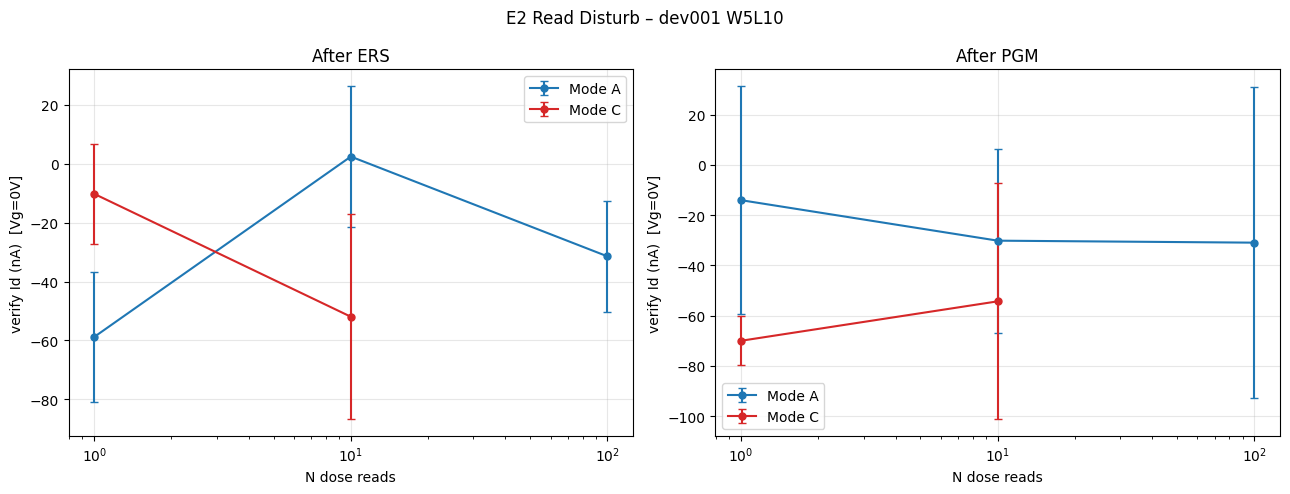

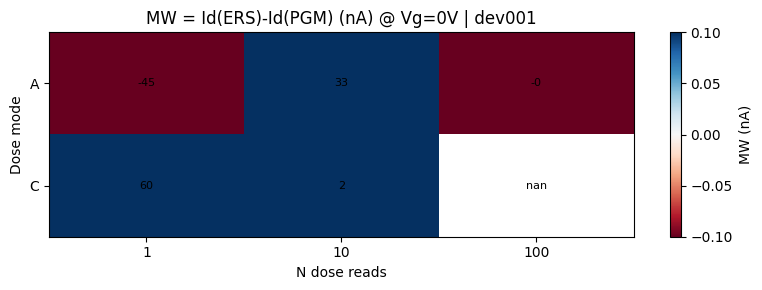

n_read           1          10      100
dose_mode                              
A         -44.758036  32.595525 -0.4865
C          59.778735   2.371688     NaN


In [7]:
df = pd.read_csv(out_csv)
vg_ref = 0.0
sub = df[df["Vg_read_V"] == vg_ref]

mode_colors = {"A": "#1f77b4", "B": "#ff7f0e", "C": "#d62728"}
states = ["ERS", "PGM"]
n_read_vals = sorted(df["n_read"].unique())
modes_plot  = sorted(df["dose_mode"].unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, state in zip(axes, states):
    sub_s = sub[sub["state_target"] == state]
    for mode in modes_plot:
        sub_m = sub_s[sub_s["dose_mode"] == mode]
        grp   = sub_m.groupby("n_read")["Id_mean_A"].agg(["mean", "std"]).reset_index()
        ax.errorbar(grp["n_read"], grp["mean"] * 1e9,
                    yerr=grp["std"] * 1e9, fmt="o-",
                    color=mode_colors.get(mode, "gray"),
                    label=f"Mode {mode}", ms=5, capsize=3)
    ax.set_xscale("log")
    ax.set_xlabel("N dose reads")
    ax.set_ylabel("verify Id (nA)  [Vg=0V]")
    ax.set_title(f"After {state}")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle(f"E2 Read Disturb – {DEVICE_ID} {GEOMETRY}")
plt.tight_layout()
plt.savefig(run_dir / "read_disturb_id_vs_nread.png", dpi=150, bbox_inches="tight")
plt.show()

# MW heatmap: MW = Id(ERS) - Id(PGM) per (mode, n_read)
ers_g  = sub[sub["state_target"] == "ERS"].groupby(["dose_mode", "n_read"])["Id_mean_A"].mean()
pgm_g  = sub[sub["state_target"] == "PGM"].groupby(["dose_mode", "n_read"])["Id_mean_A"].mean()
mw_mat = (ers_g - pgm_g).unstack(level="n_read")  # rows=mode, cols=n_read

fig2, ax2 = plt.subplots(figsize=(8, 3))
im = ax2.imshow(mw_mat.values * 1e9, aspect="auto",
               cmap="RdBu", vmin=-abs(mw_mat.values*1e9).max(),
               vmax=abs(mw_mat.values*1e9).max())
ax2.set_xticks(range(len(mw_mat.columns)))
ax2.set_xticklabels(mw_mat.columns)
ax2.set_yticks(range(len(mw_mat.index)))
ax2.set_yticklabels(mw_mat.index)
ax2.set_xlabel("N dose reads")
ax2.set_ylabel("Dose mode")
ax2.set_title(f"MW = Id(ERS)-Id(PGM) (nA) @ Vg=0V | {DEVICE_ID}")
plt.colorbar(im, ax=ax2, label="MW (nA)")
for r in range(mw_mat.shape[0]):
    for c in range(mw_mat.shape[1]):
        ax2.text(c, r, f"{mw_mat.values[r,c]*1e9:.0f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(run_dir / "read_disturb_mw_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(mw_mat * 1e9)

## 通过标准

- [ ] 无硬件错误，CSV 行完整
- [ ] Mode A MW 与 Mode C MW 有明显差异 → 读扰存在
- [ ] N_read 越大 MW 变化越大 → 量化读扰剂量依赖

**结论记录**：Mode A MW = ___ nA, Mode C (N=100) MW = ___ nA